# 07 — Synthetic Transmission Network

**Purpose:** Construct a ~500-bus synthetic transmission network for CONUS with
over-resolution in the Mountain West, using a hybrid population-plus-generation
weighting scheme. Calibrate inter-cluster transmission capacities against
observed EIA-930 interchange flows so that aggregate BA-to-BA transfer
envelopes reproduce historical observations.

**Population data:** County-level (TIGER/Line 2023 + ACS 5-year or PEP estimates).
Tract-level was the original outline spec; county-level is used here per project
decision — coarser resolution but sufficient for Mountain West over-resolution.

**Census caching:** `data/raw/census_counties/` following the pattern in 03b.

In [1]:
import sys
import json
import io
import zipfile
import datetime
import warnings
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import networkx as nx
from scipy.spatial import Delaunay as SciDelaunay
from sklearn.cluster import KMeans
from shapely.geometry import LineString, Point
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import utils

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
RAW       = PROJECT_ROOT / 'data' / 'raw'
FIGURES   = PROCESSED / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'PROCESSED    : {PROCESSED}')

PROJECT_ROOT : /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map
PROCESSED    : /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed


## Cell 2 — Configuration constants

All named constants in one place.  Edit here, not inline, so readers can
verify or challenge the methodology choices.

In [ ]:
# ── Bus allocation ─────────────────────────────────────────────────────────────
TARGET_TOTAL_BUSES     = 500
MOUNTAIN_WEST_BAS      = {'PSCO', 'WACM', 'PNM', 'WAUW', 'NWMT', 'BPAT',
                           'PACE', 'IPCO', 'NEVP', 'AZPS', 'SRP', 'EPE'}
MOUNTAIN_WEST_BUS_SHARE = 0.18   # ~90 of 500 buses — oversampling Mountain West

# ── Hybrid weighting ───────────────────────────────────────────────────────────
# w = ALPHA * pop_normalised + (1 - ALPHA) * gen_cap_normalised
POP_WEIGHT_ALPHA = 0.45

# ── Per-BA bus floors / caps ────────────────────────────────────────────────────
MIN_BUSES_PER_BA  = 1
MAX_BUSES_PER_BA  = 80    # PJM cap
WYOMING_BUS_FLOOR = 6     # ensure WY generation geography resolves

# ── Topology generation ─────────────────────────────────────────────────────────
DELAUNAY_PRUNE_DISTANCE_KM    = 75    # drop Delaunay edges longer than this
LONG_HAUL_PROBABILITY_SCALE_KM = 150  # exponential decay length scale
RANDOM_SEED = 42

# ── Capacity calibration ────────────────────────────────────────────────────────
INTERCHANGE_PERCENTILE  = 0.95
CAPACITY_HEADROOM_MULT  = 1.25

# ── Manual overlays (non-negotiable real-world infrastructure) ──────────────────
HVDC_TIES = [
    # (from_ba, to_ba, nominal_mw, name)
    # ── True HVDC ─────────────────────────────────────────────────────────────
    ('BPAT', 'CISO', 3100, 'Pacific DC Intertie (PDCI)'),
    ('PACE', 'CISO', 1920, 'Intermountain Power Project HVDC'),
    ('NEVP', 'CISO', 1200, 'McCullough-Victorville 500kV DC'),
    ('SWPP', 'WAUW',  846, 'Coal Creek-Dickinson HVDC'),
    ('SWPP', 'MISO',  500, 'Square Butte / Center-Arrowhead HVDC'),
    # HQ ties omitted — external BA, no synthetic buses
    # ── 500 kV / 765 kV AC backbone corridors ─────────────────────────────────
    ('BPAT', 'CISO', 4800, 'Northern Intertie / Path 66 500kV AC'),
    ('AZPS', 'CISO', 2400, 'Devers-Palo Verde 500kV AC (Path 42)'),
    ('MISO', 'PJM',  2200, 'MISO-PJM 765kV Seam Tie'),
    ('NEVP', 'CISO', 1200, 'Eldorado-Lugo 500kV AC (Path 46)'),
    ('BPAT', 'PACW', 1200, 'John Day-Grizzly 500kV AC'),
    ('BPAT', 'NEVP', 1200, 'Pacific Intertie BPA-NV Energy segment'),
    ('PACE', 'PACW', 1200, 'PacifiCorp East-West 500kV AC'),
    ('AZPS', 'SRP',  1200, 'Palo Verde Hub APS-SRP 500kV AC'),
    ('WACM', 'AZPS', 1200, 'Four Corners-Navajo 500kV AC'),
    ('MISO', 'SWPP', 1200, 'West New Madrid-Dell 500kV AC'),
    ('MISO', 'TVA',  1200, 'MISO-TVA 500kV AC Tie'),
    ('TVA',  'PJM',  1200, 'TVA-Dominion PJM 500kV AC'),
    ('NYIS', 'ISNE', 1200, 'NYISO-ISNE 500kV AC Tie'),
    ('PJM',  'NYIS', 1200, 'PJM-NYISO AC Seam Tie'),
    ('SOCO', 'TVA',  1200, 'Southern Company-TVA 500kV AC'),
    # ── LOW confidence — verify but include as placeholders ───────────────────
    ('CISO', 'AZPS', 1200, 'Colorado River 500kV boundary tie'),
    ('NEVP', 'AZPS', 1200, 'Mohave 500kV boundary tie'),
]
EHV_BACKBONE_CORRIDORS = []   # populated when 500 kV corridors are manually coded

# ── Wyoming state FIPS ─────────────────────────────────────────────────────────
WY_STATEFP = '56'

print('Configuration loaded.')
print(f'  Target buses         : {TARGET_TOTAL_BUSES}')
print(f'  Mountain West BAs    : {sorted(MOUNTAIN_WEST_BAS)}')
print(f'  Wyoming bus floor    : {WYOMING_BUS_FLOOR}')
print(f'  Random seed          : {RANDOM_SEED}')

## Cell 3 — Load existing project artifacts

Read all inputs produced by notebooks 01–03b.  Validate CRS consistency
and print summary statistics to confirm data quality before building.

In [3]:
# ── BA territories ─────────────────────────────────────────────────────────────
ba_territories = gpd.read_file(PROCESSED / 'ba_territories.geojson')
# Normalise column names (HIFLD GeoJSON uses BA_Abbrev; legacy shapefiles use ba_code)
if 'ba_code' not in ba_territories.columns:
    for alias in ('BA_Abbrev', 'BACODE', 'EIACode'):
        if alias in ba_territories.columns:
            ba_territories = ba_territories.rename(columns={alias: 'ba_code'})
            break
if 'ba_name' not in ba_territories.columns:
    for alias in ('BAL_AUTH', 'NAME', 'ba_name'):
        if alias in ba_territories.columns:
            ba_territories = ba_territories.rename(columns={alias: 'ba_name'})
            break
ba_territories = ba_territories[ba_territories['ba_code'].notna()].copy()
print(f'BA territories : {len(ba_territories)} BAs, CRS: {ba_territories.crs}')

# ── Power plants (with BA assignments from 03a) ────────────────────────────────
plants = gpd.read_file(PROCESSED / 'power_plants_with_ba.geojson')
plants['capacity_mw'] = pd.to_numeric(plants['capacity_mw'], errors='coerce').fillna(0)
print(f'Power plants   : {len(plants):,} rows, total cap {plants["capacity_mw"].sum():,.0f} MW')
print(f'  BAs covered  : {plants["ba_code"].nunique()}')

# ── BA capacity summary ────────────────────────────────────────────────────────
ba_capacity = pd.read_csv(PROCESSED / 'ba_capacity_summary.csv')
if 'ba_code' in ba_capacity.columns:
    ba_capacity = ba_capacity.set_index('ba_code')
print(f'BA capacity    : {len(ba_capacity)} BAs')

# ── EIA-930 hourly interchange ─────────────────────────────────────────────────
eia930 = pd.read_parquet(PROCESSED / 'eia930_raw.parquet')
print(f'EIA-930        : {len(eia930):,} rows, {eia930["fromba"].nunique()} from-BAs')
if 'period' in eia930.columns:
    print(f'  Date range   : {eia930["period"].min()} → {eia930["period"].max()}')

# ── BA demand (mean MW from EIA-930 balance) ───────────────────────────────────
ba_demand_raw = pd.read_csv(PROCESSED / 'ba_demand_mw.csv')
ba_mean_demand = ba_demand_raw.set_index('ba_code')['mean_demand_mw'].to_dict()
print(f'BA demand      : {len(ba_mean_demand)} BAs, total {sum(ba_mean_demand.values()):,.0f} MW')

# ── Generators with costs ──────────────────────────────────────────────────────
gen_costs = pd.read_parquet(PROCESSED / 'generators_with_costs.parquet')
print(f'Gen with costs : {len(gen_costs):,} rows')

# ── CRS validation ─────────────────────────────────────────────────────────────
assert ba_territories.crs.to_epsg() == 4326, 'BA territories must be EPSG:4326'
assert plants.crs.to_epsg() == 4326, 'Power plants must be EPSG:4326'
print('\nAll inputs loaded. CRS validated (EPSG:4326).')

BA territories : 85 BAs, CRS: EPSG:4326


Power plants   : 15,034 rows, total cap 1,025,326 MW
  BAs covered  : 67
BA capacity    : 67 BAs


EIA-930        : 2,584,201 rows, 62 from-BAs
  Date range   : 2023-01-01 06:00:00+00:00 → 2024-01-01 08:00:00+00:00
BA demand      : 53 BAs, total 465,658 MW
Gen with costs : 14,354 rows

All inputs loaded. CRS validated (EPSG:4326).


## Cell 4 — Fetch Census TIGER/Line county data

**Modified from outline:** uses county-level data instead of census tract level.
County resolution (~3,100 CONUS counties) is coarser than tracts (~85k) but
sufficient for the Mountain West over-resolution goal.

Geometry: TIGER/Line 2023 county shapefile  
Population (priority order):
1. ACS 5-year via Census API (no key required, rate-limited)
2. Census Bureau Population Estimates Program CSV (2020-based, no key)

All files cached in `data/raw/census_counties/` following the 03b pattern.

In [4]:
CENSUS_RAW_DIR = RAW / 'census_counties'
CENSUS_RAW_DIR.mkdir(parents=True, exist_ok=True)

# ── Download TIGER/Line 2023 county shapefile ──────────────────────────────────
COUNTY_ZIP_URL  = 'https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip'
COUNTY_ZIP_PATH = CENSUS_RAW_DIR / 'tl_2023_us_county.zip'
COUNTY_SHP_PATH = CENSUS_RAW_DIR / 'tl_2023_us_county.shp'

if COUNTY_SHP_PATH.exists():
    print(f'County shapefile already cached: {COUNTY_SHP_PATH.name}')
else:
    print(f'Downloading county shapefile...', end=' ', flush=True)
    r = requests.get(COUNTY_ZIP_URL, timeout=300, stream=True)
    r.raise_for_status()
    COUNTY_ZIP_PATH.write_bytes(r.content)
    print(f'{COUNTY_ZIP_PATH.stat().st_size / 1024 / 1024:.1f} MB')
    print('Extracting...', end=' ', flush=True)
    with zipfile.ZipFile(COUNTY_ZIP_PATH) as zf:
        zf.extractall(CENSUS_RAW_DIR)
    print('done.')

counties_gdf = gpd.read_file(COUNTY_SHP_PATH)
print(f'County shapefile: {len(counties_gdf):,} rows, CRS: {counties_gdf.crs}')

if counties_gdf.crs.to_epsg() != 4326:
    counties_gdf = counties_gdf.to_crs(epsg=4326)

# ── Filter to CONUS ────────────────────────────────────────────────────────────
# Exclude AK (02), HI (15), and US territories (60 AS, 66 GU, 69 MP, 72 PR, 78 VI)
EXCLUDE_FIPS = {'02', '15', '60', '66', '69', '72', '78'}
counties_gdf = counties_gdf[~counties_gdf['STATEFP'].isin(EXCLUDE_FIPS)].copy()
counties_gdf['GEOID'] = counties_gdf['STATEFP'] + counties_gdf['COUNTYFP']
print(f'CONUS counties : {len(counties_gdf):,}')

County shapefile already cached: tl_2023_us_county.shp


County shapefile: 3,235 rows, CRS: EPSG:4269


CONUS counties : 3,109


In [5]:
# ── Fetch county population ────────────────────────────────────────────────────
# Strategy: (1) Census API ACS 5-year — free, no key needed for single batch query
#           (2) Census Bureau PEP county estimates CSV — 2020-based, no key needed

POP_CSV_PATH = CENSUS_RAW_DIR / 'county_population.csv'
pop_df = None

if POP_CSV_PATH.exists():
    print(f'Population cache hit: {POP_CSV_PATH.name}')
    pop_df = pd.read_csv(POP_CSV_PATH, dtype={'GEOID': str})

else:
    # ── Attempt 1: Census API ACS 5-year (no API key required) ────────────────
    try:
        ACS_URL = (
            'https://api.census.gov/data/2022/acs/acs5'
            '?get=B01003_001E,NAME&for=county:*&in=state:*'
        )
        print('Fetching ACS 5-year county population via Census API...', end=' ', flush=True)
        r = requests.get(ACS_URL, timeout=120)
        r.raise_for_status()
        data = r.json()
        headers = data[0]
        raw = pd.DataFrame(data[1:], columns=headers)
        raw['GEOID'] = raw['state'].str.zfill(2) + raw['county'].str.zfill(3)
        raw['population'] = pd.to_numeric(raw['B01003_001E'], errors='coerce')
        pop_df = raw[['GEOID', 'population']].dropna().copy()
        print(f'{len(pop_df):,} counties')
    except Exception as e:
        print(f'Census API failed: {e}')
        pop_df = None

    # ── Attempt 2: Census PEP county estimates CSV (2020-based, no key) ───────
    if pop_df is None or len(pop_df) < 100:
        PEP_URL = (
            'https://www2.census.gov/programs-surveys/popest/datasets/'
            '2020-2022/counties/totals/co-est2022-alldata.csv'
        )
        print(f'Falling back to Census PEP county estimates...', end=' ', flush=True)
        r = requests.get(PEP_URL, timeout=120)
        r.raise_for_status()
        pep = pd.read_csv(io.StringIO(r.text), encoding='latin-1')
        # SUMLEV == 50 → county-level records; drop state totals (SUMLEV == 40)
        pep = pep[pep['SUMLEV'] == 50].copy()
        pep['GEOID'] = pep['STATE'].astype(str).str.zfill(2) + pep['COUNTY'].astype(str).str.zfill(3)
        pop_df = pep[['GEOID', 'POPESTIMATE2022']].rename(columns={'POPESTIMATE2022': 'population'}).copy()
        print(f'{len(pop_df):,} counties (PEP 2022)')

    # ── Cache ──────────────────────────────────────────────────────────────────
    pop_df.to_csv(POP_CSV_PATH, index=False)
    print(f'Cached → {POP_CSV_PATH}')

pop_df['GEOID'] = pop_df['GEOID'].astype(str).str.zfill(5)
pop_df['population'] = pd.to_numeric(pop_df['population'], errors='coerce').fillna(0)
print(f'\nPopulation data: {len(pop_df):,} counties, total pop {pop_df["population"].sum():,.0f}')

# ── Join population to county geometries ───────────────────────────────────────
counties_gdf = counties_gdf.merge(pop_df[['GEOID', 'population']], on='GEOID', how='left')
counties_gdf['population'] = counties_gdf['population'].fillna(0)

matched_pop = counties_gdf['population'].gt(0).sum()
print(f'Counties with population > 0: {matched_pop:,} / {len(counties_gdf):,}')
print(f'\nOutput: counties_gdf — {len(counties_gdf):,} CONUS counties')

Population cache hit: county_population.csv

Population data: 3,222 counties, total pop 334,369,975
Counties with population > 0: 3,109 / 3,109

Output: counties_gdf — 3,109 CONUS counties


## Cell 5 — Compute county-level hybrid weights

**Modified from outline:** tract-level logic ported to county level.  The
same five-step formula applies; spatial resolution is coarser.

For each CONUS county:
1. Assign to a BA (centroid-in-polygon join)
2. `pop_share_within_ba` = county_pop / ba_pop_total
3. `gen_cap_in_county` = sum of generator nameplate_mw in county
4. `gen_share_within_ba` = county_gen / ba_gen_total
5. `hybrid_weight` = α·pop_share + (1-α)·gen_share

In [6]:
# ── Step 1: Assign each county to a BA by centroid ────────────────────────────
counties_proj = counties_gdf.to_crs(epsg=5070)
centroids_4326 = counties_proj.geometry.centroid.to_crs(epsg=4326)
counties_gdf['centroid_lon'] = centroids_4326.x
counties_gdf['centroid_lat'] = centroids_4326.y

centroids_gdf = gpd.GeoDataFrame(
    counties_gdf[['GEOID', 'population', 'centroid_lon', 'centroid_lat']].copy(),
    geometry=gpd.points_from_xy(counties_gdf['centroid_lon'], counties_gdf['centroid_lat']),
    crs='EPSG:4326'
)

counties_ba = gpd.sjoin(
    centroids_gdf,
    ba_territories[['ba_code', 'ba_name', 'geometry']],
    how='left',
    predicate='within'
)
# Drop duplicate matches (rare at BA boundaries)
counties_ba = counties_ba.drop_duplicates(subset='GEOID').copy()

n_assigned = counties_ba['ba_code'].notna().sum()
print(f'Counties assigned to a BA: {n_assigned:,} / {len(counties_ba):,} '
      f'({100*n_assigned/len(counties_ba):.1f}%)')
counties_ba = counties_ba.dropna(subset=['ba_code']).copy()

# ── Step 2: pop_share_within_ba ───────────────────────────────────────────────
ba_pop_total = counties_ba.groupby('ba_code')['population'].sum().rename('ba_pop_total')
counties_ba = counties_ba.join(ba_pop_total, on='ba_code')
counties_ba['pop_share_within_ba'] = (
    counties_ba['population'] / counties_ba['ba_pop_total'].clip(lower=1)
)

# ── Step 3: gen_cap_in_county (spatial join of plants → counties) ─────────────
county_polygons = counties_gdf[['GEOID', 'geometry']].copy()
plants_for_join = plants[['geometry', 'capacity_mw']].copy()

plants_county = gpd.sjoin(plants_for_join, county_polygons, how='left', predicate='within')
county_gen = (
    plants_county.groupby('GEOID')['capacity_mw']
    .sum()
    .rename('gen_cap_in_county')
    .reset_index()
)
counties_ba = counties_ba.merge(county_gen, on='GEOID', how='left')
counties_ba['gen_cap_in_county'] = counties_ba['gen_cap_in_county'].fillna(0)

# ── Step 4: gen_share_within_ba ───────────────────────────────────────────────
ba_gen_total = counties_ba.groupby('ba_code')['gen_cap_in_county'].sum().rename('ba_gen_total')
counties_ba = counties_ba.join(ba_gen_total, on='ba_code')
counties_ba['gen_share_within_ba'] = (
    counties_ba['gen_cap_in_county'] / counties_ba['ba_gen_total'].clip(lower=1)
)

# ── Step 5: hybrid_weight ─────────────────────────────────────────────────────
counties_ba['hybrid_weight'] = (
    POP_WEIGHT_ALPHA * counties_ba['pop_share_within_ba']
    + (1 - POP_WEIGHT_ALPHA) * counties_ba['gen_share_within_ba']
)

# ── Sanity check: weight sums within each BA should be ~1.0 ──────────────────
weight_sums = counties_ba.groupby('ba_code')['hybrid_weight'].sum()
print(f'\nHybrid weight sum per BA (target ~1.0):')
print(f'  min={weight_sums.min():.3f}  max={weight_sums.max():.3f}  '
      f'mean={weight_sums.mean():.3f}')

# ── Wyoming sanity check ──────────────────────────────────────────────────────
wy_all = counties_ba[counties_ba['GEOID'].str.startswith(WY_STATEFP)].copy()
print(f'\nWyoming counties in dataset: {len(wy_all)}')
print(f'  In WACM territory: {(wy_all["ba_code"] == "WACM").sum()}')
print('\nTop Wyoming counties by hybrid_weight (generation-heavy should lead):')
wy_top = wy_all.nlargest(8, 'hybrid_weight')[
    ['GEOID', 'ba_code', 'population', 'gen_cap_in_county', 'hybrid_weight']
]
print(wy_top.to_string(index=False))

Counties assigned to a BA: 3,056 / 3,109 (98.3%)



Hybrid weight sum per BA (target ~1.0):
  min=0.450  max=1.000  mean=0.990

Wyoming counties in dataset: 23
  In WACM territory: 11

Top Wyoming counties by hybrid_weight (generation-heavy should lead):
GEOID ba_code  population  gen_cap_in_county  hybrid_weight
56037    PACE       42079             2395.0       0.116477
56031    WACM        8618             1907.4       0.067788
56005    WACM       46857             1361.8       0.056114
56009    WACM       13729             1397.1       0.051058
56023    PACE       19794              864.4       0.042624
56021    WACM      100316              211.4       0.026347
56025    WACM       79506              125.2       0.019413
56007    PACE       14609              365.9       0.018834


In [7]:
# ── Fix 5b: Proportional county → BA assignment ──────────────────────────────
# Winner-takes-all max-overlap fails for small BAs (SRP, EPE, NWMT) that don't
# fully contain any county.  Proportional allocation splits each county's
# population and generation across every BA it overlaps, weighted by the
# fraction of county area that falls in each BA.
#
# counties_ba rows: one per (county, BA) fragment — a county touching k BAs
# contributes k rows, each weighted by its overlap fraction.
# Cell 7 k-means clusters fragment centroids (= county centroids) with
# hybrid_weight as the sample weight, so a county that is 80 % in BA A and
# 20 % in BA B contributes to both clusters in the right proportions.

import warnings
warnings.filterwarnings('ignore')

# ── Step 0: Repair BA geometries (buffer(0) fixes self-intersecting rings) ────
n_before = (~ba_territories.geometry.is_valid).sum()
print(f'BA geometries invalid BEFORE buffer(0): {n_before} / {len(ba_territories)}')
if n_before:
    print('  Invalid:', ba_territories.loc[~ba_territories.geometry.is_valid, 'ba_code'].tolist())
ba_territories.geometry = ba_territories.geometry.buffer(0)
n_after = (~ba_territories.geometry.is_valid).sum()
print(f'BA geometries invalid AFTER  buffer(0): {n_after} / {len(ba_territories)}')

# ── Step 1: Project to EPSG:5070 and compute county areas ────────────────────
counties_5070 = counties_gdf[['GEOID', 'geometry']].to_crs(epsg=5070).copy()
ba_5070       = ba_territories[['ba_code', 'ba_name', 'geometry']].to_crs(epsg=5070)

assert counties_5070.crs.to_epsg() == 5070, 'counties CRS must be EPSG:5070'
assert ba_5070.crs.to_epsg()       == 5070, 'BA CRS must be EPSG:5070'
print(f'\nCRS check passed (EPSG:5070)  |  counties: {len(counties_5070):,}  |  BAs: {len(ba_5070)}')

counties_5070['county_area'] = counties_5070.geometry.area   # m²

# ── Step 2: Overlay — keep ALL county × BA fragment rows ─────────────────────
# Every row is one (county, BA) intersection polygon; a county touching k BAs
# produces k rows.  frag_area / county_area = proportional overlap fraction.
print('\nComputing county × BA intersections (proportional, may take 1–2 min)...')
overlay_df = gpd.overlay(counties_5070, ba_5070,
                          how='intersection', keep_geom_type=False)
overlay_df['frag_area'] = overlay_df.geometry.area

# county_area came through from counties_5070
overlay_df['frac'] = (
    overlay_df['frag_area'] / overlay_df['county_area'].clip(lower=1)
).clip(0.0, 1.0)

n_frags = len(overlay_df)
n_cty   = overlay_df['GEOID'].nunique()
print(f'Overlay rows: {n_frags:,}  (counties covered: {n_cty:,}, '
      f'avg {n_frags/n_cty:.2f} BAs per county)')
print(f'  SRP fragments : {(overlay_df["ba_code"] == "SRP").sum()}')

# ── Step 3: Join county-level attributes ─────────────────────────────────────
county_attrs = counties_gdf[['GEOID', 'STATEFP', 'population',
                              'centroid_lon', 'centroid_lat']].copy()
overlay_df = overlay_df.merge(county_attrs, on='GEOID', how='left')
overlay_df = overlay_df.merge(county_gen[['GEOID', 'gen_cap_in_county']],
                               on='GEOID', how='left')
overlay_df['population']       = overlay_df['population'].fillna(0)
overlay_df['gen_cap_in_county'] = overlay_df['gen_cap_in_county'].fillna(0)

# ── Step 4: Scale population and generation by overlap fraction ───────────────
overlay_df['population']       = overlay_df['population']       * overlay_df['frac']
overlay_df['gen_cap_in_county'] = overlay_df['gen_cap_in_county'] * overlay_df['frac']

# ── Step 5: Build counties_ba (one row per county-BA fragment) ───────────────
counties_ba = overlay_df[[
    'GEOID', 'STATEFP', 'ba_code', 'ba_name',
    'centroid_lon', 'centroid_lat', 'frac',
    'population', 'gen_cap_in_county'
]].copy().reset_index(drop=True)

# ── Step 6: Recompute shares and hybrid weights within each BA ────────────────
ba_pop_total = counties_ba.groupby('ba_code')['population'].sum().rename('ba_pop_total')
ba_gen_total = counties_ba.groupby('ba_code')['gen_cap_in_county'].sum().rename('ba_gen_total')
counties_ba  = counties_ba.join(ba_pop_total, on='ba_code')
counties_ba  = counties_ba.join(ba_gen_total, on='ba_code')

counties_ba['pop_share_within_ba'] = (
    counties_ba['population'] / counties_ba['ba_pop_total'].clip(lower=1)
)
counties_ba['gen_share_within_ba'] = (
    counties_ba['gen_cap_in_county'] / counties_ba['ba_gen_total'].clip(lower=1)
)
counties_ba['hybrid_weight'] = (
    POP_WEIGHT_ALPHA * counties_ba['pop_share_within_ba']
    + (1 - POP_WEIGHT_ALPHA) * counties_ba['gen_share_within_ba']
)

# ── Sanity checks ─────────────────────────────────────────────────────────────
ws = counties_ba.groupby('ba_code')['hybrid_weight'].sum()
print(f'\nHybrid weight sums per BA: min={ws.min():.3f}  max={ws.max():.3f}')

print('\nPopulation / generation spot-check (must be nonzero for SRP):')
for chk in ['SRP', 'AZPS', 'WACM', 'BPAT']:
    r = counties_ba[counties_ba['ba_code'] == chk]
    print(f'  {chk:6s}: {len(r):4d} fragments, '
          f'pop={r["population"].sum()/1e6:.2f}M, '
          f'gen={r["gen_cap_in_county"].sum():.0f} MW')

# EPE and NWMT have no ba_territories polygon → absent from overlay →
# Cell 7 places their single bus at mean EIA plant location (unchanged).
print('\ncounties_ba rebuilt with proportional allocation. Proceed to Cell 6.')


BA geometries invalid BEFORE buffer(0): 20 / 85
  Invalid: ['AZPS', 'AECI', 'BPAT', 'CISO', 'CEA', 'FPC', 'CPLE', 'EKPC', 'FPL', 'LGEE', 'LDWP', 'MISO', 'NEVP', 'NSB', 'PJM', 'PSEI', 'SEC', 'SWPP', 'TEC', 'WACM']


BA geometries invalid AFTER  buffer(0): 0 / 85



CRS check passed (EPSG:5070)  |  counties: 3,109  |  BAs: 85

Computing county × BA intersections (proportional, may take 1–2 min)...


Overlay rows: 4,662  (counties covered: 3,109, avg 1.50 BAs per county)
  SRP fragments : 4

Hybrid weight sums per BA: min=0.450  max=1.000

Population / generation spot-check (must be nonzero for SRP):
  SRP   :    4 fragments, pop=1.04M, gen=3685 MW
  AZPS  :   25 fragments, pop=6.44M, gen=23679 MW
  WACM  :  108 fragments, pop=2.58M, gen=15537 MW
  BPAT  :   99 fragments, pop=6.78M, gen=23711 MW

counties_ba rebuilt with proportional allocation. Proceed to Cell 6.


In [8]:
# ── DIAGNOSTIC: SRP overlay inspection ───────────────────────────────────────
# Run this cell after Fix 5b to see exactly what the overlay produces for SRP.
# Do NOT proceed to Cell 6 until this confirms SRP is correctly assigned.

import warnings
warnings.filterwarnings('ignore')

# 1. Exact ba_code for SRP in the live ba_territories GeoDataFrame
srp_rows = ba_territories[ba_territories['ba_code'].str.strip() == 'SRP']
print('1. SRP rows in ba_territories:')
print(f'   count = {len(srp_rows)}')
if len(srp_rows):
    print(f'   ba_code repr = {repr(srp_rows["ba_code"].iloc[0])}')
    print(f'   geometry type = {srp_rows.geometry.iloc[0].geom_type}')
    print(f'   geometry valid = {srp_rows.geometry.iloc[0].is_valid}')
    b = srp_rows.geometry.total_bounds   # [minx, miny, maxx, maxy]
    print(f'   bounds (EPSG:4326): lon {b[0]:.4f}..{b[2]:.4f}  lat {b[1]:.4f}..{b[3]:.4f}')
print()

# 2. Quick sjoin (intersects) — county polygons touching SRP
az_counties = counties_gdf[counties_gdf['STATEFP'] == '04'][['GEOID', 'NAME', 'geometry']].copy()
srp_poly    = ba_territories[ba_territories['ba_code'] == 'SRP'][['ba_code', 'geometry']]

touch_test = gpd.sjoin(az_counties, srp_poly, how='left', predicate='intersects')
touching   = touch_test[touch_test['ba_code'].notna()]
print('2. Arizona counties whose polygon INTERSECTS the SRP polygon:')
if len(touching):
    print(touching[['GEOID', 'NAME', 'ba_code']].to_string(index=False))
else:
    print('   NONE — SRP polygon does not intersect any Arizona county polygon')
    print('   (possible invalid geometry or CRS issue)')
print()

# 3. Overlay result inspection — run on Arizona only (fast)
az_5070  = az_counties[['GEOID', 'geometry']].to_crs(epsg=5070)
ba_5070  = ba_territories[ba_territories['ba_code'].isin({'SRP', 'AZPS', 'TEPC'})] \
               [['ba_code', 'ba_name', 'geometry']].to_crs(epsg=5070)

print('3. gpd.overlay (intersection) for Arizona counties × {SRP, AZPS, TEPC}:')
print(f'   AZ county polygons: {len(az_5070)}')
print(f'   BA polygons included: {ba_5070["ba_code"].tolist()}')
try:
    ov = gpd.overlay(az_5070, ba_5070, how='intersection', keep_geom_type=False)
    ov['isect_area_km2'] = ov.geometry.area / 1e6
    print(f'   Overlay rows returned: {len(ov)}')
    if len(ov):
        print(f'   Columns: {ov.columns.tolist()}')
        top5 = ov.nlargest(5, 'isect_area_km2')[['GEOID', 'ba_code', 'isect_area_km2']]
        print('   Top 5 rows by intersection area:')
        print(top5.to_string(index=False))
        print()
        print('   Max-overlap BA per county:')
        best = (ov.sort_values('isect_area_km2', ascending=False)
                  .drop_duplicates(subset='GEOID')[['GEOID', 'ba_code', 'isect_area_km2']])
        print(best.to_string(index=False))
    else:
        print('   Overlay returned EMPTY — checking for geometry validity...')
        print(f'   AZ counties valid: {az_5070.geometry.is_valid.all()}')
        print(f'   BA geoms valid:    {ba_5070.geometry.is_valid.all()}')
        print('   Invalid BA geometries:')
        print(ba_5070[~ba_5070.geometry.is_valid][['ba_code']])
except Exception as e:
    print(f'   Overlay FAILED: {type(e).__name__}: {e}')


1. SRP rows in ba_territories:
   count = 1
   ba_code repr = 'SRP'
   geometry type = Polygon
   geometry valid = True
   bounds (EPSG:4326): lon -112.3393..-110.8238  lat 33.0966..34.0089

2. Arizona counties whose polygon INTERSECTS the SRP polygon:
GEOID     NAME ba_code
04021    Pinal     SRP
04013 Maricopa     SRP
04007     Gila     SRP
04025  Yavapai     SRP

3. gpd.overlay (intersection) for Arizona counties × {SRP, AZPS, TEPC}:
   AZ county polygons: 15
   BA polygons included: ['AZPS', 'SRP', 'TEPC']
   Overlay rows returned: 23
   Columns: ['GEOID', 'ba_code', 'ba_name', 'geometry', 'isect_area_km2']
   Top 5 rows by intersection area:
GEOID ba_code  isect_area_km2
04005    AZPS    42026.941099
04013    AZPS    23895.236744
04001    AZPS    23724.214612
04017    AZPS    21639.044308
04025    AZPS    21046.765981

   Max-overlap BA per county:
GEOID ba_code  isect_area_km2
04005    AZPS    42026.941099
04013    AZPS    23895.236744
04001    AZPS    23724.214612
04017    AZPS 

## Cell 6 — Allocate bus counts to BAs

Base allocation proportional to BA mean demand; Mountain West BAs are
oversampled to the configured share.  Integer programming via iterative
adjustment rescales the allocation to exactly TARGET_TOTAL_BUSES.

In [9]:
# ── Base allocation ────────────────────────────────────────────────────────────
all_ba_codes = ba_territories['ba_code'].dropna().unique().tolist()

# Add Mountain West BAs absent from ba_territories (EPE, NWMT not in HIFLD data)
polygon_missing_mw = sorted(MOUNTAIN_WEST_BAS - set(all_ba_codes))
if polygon_missing_mw:
    print(f'MW BAs absent from ba_territories: {polygon_missing_mw}')
    print('  These BAs have no HIFLD polygon. Buses will be placed at EIA plant '
          'centroid in Cell 7; k_buses=1 (MIN_BUSES_PER_BA floor).')
    all_ba_codes.extend(polygon_missing_mw)

total_load   = sum(ba_mean_demand.get(ba, 0) for ba in all_ba_codes)
if total_load == 0:
    total_load = 1

mw_load_total = sum(
    ba_mean_demand.get(ba, 0) for ba in MOUNTAIN_WEST_BAS if ba in ba_mean_demand
)

bus_alloc_rows = []
for ba in all_ba_codes:
    ba_load = ba_mean_demand.get(ba, 0)

    if ba in MOUNTAIN_WEST_BAS and mw_load_total > 0:
        mw_target    = MOUNTAIN_WEST_BUS_SHARE * TARGET_TOTAL_BUSES
        mw_frac      = ba_load / mw_load_total
        base         = mw_target * mw_frac
    else:
        non_mw_total = total_load - mw_load_total
        non_mw_buses = (1 - MOUNTAIN_WEST_BUS_SHARE) * TARGET_TOTAL_BUSES
        base         = non_mw_buses * (ba_load / max(non_mw_total, 1))

    k = int(np.clip(round(base), MIN_BUSES_PER_BA, MAX_BUSES_PER_BA))
    bus_alloc_rows.append({
        'ba_code': ba,
        'ba_load_mw': ba_load,
        'base_allocation': base,
        'k_buses': k,
        'is_mountain_west': ba in MOUNTAIN_WEST_BAS
    })

bus_alloc_df = pd.DataFrame(bus_alloc_rows)

# ── Rescale to exactly TARGET_TOTAL_BUSES via iterative adjustment ─────────────
delta = TARGET_TOTAL_BUSES - bus_alloc_df['k_buses'].sum()
print(f'Pre-rescale total: {bus_alloc_df["k_buses"].sum()}  (delta={delta})')

if delta != 0:
    step = 1 if delta > 0 else -1
    sorted_idx = bus_alloc_df['base_allocation'].argsort()[::-1].values
    for i in range(abs(delta)):
        idx = sorted_idx[i % len(sorted_idx)]
        new_k = bus_alloc_df.loc[idx, 'k_buses'] + step
        bus_alloc_df.loc[idx, 'k_buses'] = int(
            np.clip(new_k, MIN_BUSES_PER_BA, MAX_BUSES_PER_BA)
        )

print(f'Post-rescale total: {bus_alloc_df["k_buses"].sum()}')

# ── Print allocation table ─────────────────────────────────────────────────────
display_df = bus_alloc_df.sort_values(
    ['is_mountain_west', 'k_buses'], ascending=[False, False]
)[['ba_code', 'ba_load_mw', 'k_buses', 'is_mountain_west']]
print(f'\nBus allocation table (Mountain West first):')
print(display_df.to_string(index=False))


MW BAs absent from ba_territories: ['EPE', 'NWMT']
  These BAs have no HIFLD polygon. Buses will be placed at EIA plant centroid in Cell 7; k_buses=1 (MIN_BUSES_PER_BA floor).
Pre-rescale total: 534  (delta=-34)
Post-rescale total: 500

Bus allocation table (Mountain West first):
ba_code   ba_load_mw  k_buses  is_mountain_west
   BPAT  6582.683219       14              True
   PACE  5792.251826       12              True
   PSCO  4841.235046       10              True
   NEVP  4397.228539        9              True
   AZPS  3836.496005        8              True
    SRP  3871.329452        8              True
   WACM  3692.630708        7              True
   IPCO  2087.239041        4              True
    PNM  1668.102968        3              True
   NWMT  1363.751256        2              True
   WAUW    94.776370        1              True
    EPE  1044.081050        1              True
    PJM 89606.517982       79             False
   MISO 73172.155479       69             False

## Cell 7 — Weighted k-means clustering within each BA

For each BA, cluster county centroids weighted by `hybrid_weight`.  Wyoming
receives special handling to guarantee at least `WYOMING_BUS_FLOOR` buses
within WY state bounds before the calibration pipeline runs.

In [10]:
wy_geoids = set(counties_gdf[counties_gdf['STATEFP'] == WY_STATEFP]['GEOID'])

bus_rows = []
bus_id_counter = 0

for _, ba_row in bus_alloc_df.iterrows():
    ba   = ba_row['ba_code']
    k    = int(ba_row['k_buses'])

    ba_counties = counties_ba[counties_ba['ba_code'] == ba].copy()

    # ── Degenerate: no counties mapped to this BA ──────────────────────────────
    if len(ba_counties) == 0:
        ba_geom = ba_territories[ba_territories['ba_code'] == ba]
        if len(ba_geom) > 0:
            # BA has a territory polygon — place bus at its centroid
            c = ba_geom.geometry.to_crs(epsg=5070).centroid.to_crs(epsg=4326).iloc[0]
            lon, lat = c.x, c.y
        else:
            # No territory polygon (EPE, NWMT absent from HIFLD) —
            # fall back to mean location of EIA-coded plants
            eia_plants = plants[plants['balancing_authority_code'] == ba]
            if len(eia_plants) == 0:
                print(f'  SKIP {ba}: no polygon and no EIA plants — omitted from network')
                continue
            lon = pd.to_numeric(eia_plants['longitude'], errors='coerce').mean()
            lat = pd.to_numeric(eia_plants['latitude'], errors='coerce').mean()
            print(f'  {ba}: no HIFLD polygon → placed at EIA plant centroid '
                  f'({lon:.2f}, {lat:.2f}), '
                  f'{len(eia_plants)} plants, {eia_plants["capacity_mw"].sum():.0f} MW')
        gen_cap = float(
            plants[plants['balancing_authority_code'] == ba]['capacity_mw'].sum()
        )
        bus_rows.append({
            'bus_id': bus_id_counter, 'ba_code': ba,
            'lon': lon, 'lat': lat,
            'n_counties': 0, 'population': 0.0,
            'generation_cap_mw': gen_cap
        })
        bus_id_counter += 1
        continue

    # ── Project county centroids to EPSG:5070 for Euclidean clustering ─────────
    tmp = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(
            ba_counties['centroid_lon'], ba_counties['centroid_lat']
        ),
        crs='EPSG:4326'
    ).to_crs(epsg=5070)
    coords = np.column_stack([tmp.geometry.x.values, tmp.geometry.y.values])

    weights = ba_counties['hybrid_weight'].fillna(1e-9).clip(lower=1e-9).values

    # ── Wyoming floor: boost k if WY counties would be under-clustered ─────────
    if ba == 'WACM':
        wy_mask = ba_counties['GEOID'].isin(wy_geoids).values
        n_wy    = wy_mask.sum()
        if n_wy > 0:
            wy_weight_share = weights[wy_mask].sum() / weights.sum()
            wy_natural_k    = max(1, round(k * wy_weight_share))
            if wy_natural_k < WYOMING_BUS_FLOOR:
                extra = WYOMING_BUS_FLOOR - wy_natural_k
                k     = min(k + extra, MAX_BUSES_PER_BA)

    k = min(k, len(ba_counties))   # cannot cluster more than we have points

    if k == 1:
        labels    = np.zeros(len(ba_counties), dtype=int)
        centroids = coords.mean(axis=0, keepdims=True)
    else:
        km        = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
        km.fit(coords, sample_weight=weights)
        labels    = km.labels_
        centroids = km.cluster_centers_

    # ── Convert cluster centres back to EPSG:4326 ──────────────────────────────
    c_gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(centroids[:, 0], centroids[:, 1]),
        crs='EPSG:5070'
    ).to_crs(epsg=4326)

    # ── Aggregate county attributes per cluster ────────────────────────────────
    ba_counties = ba_counties.copy()
    ba_counties['cluster'] = labels
    cl_agg = ba_counties.groupby('cluster').agg(
        n_counties=('GEOID', 'count'),
        population=('population', 'sum'),
        generation_cap_mw=('gen_cap_in_county', 'sum')
    ).reset_index()

    for _, cl in cl_agg.iterrows():
        ci = int(cl['cluster'])
        pt = c_gdf.iloc[ci]
        bus_rows.append({
            'bus_id': bus_id_counter, 'ba_code': ba,
            'lon': pt.geometry.x, 'lat': pt.geometry.y,
            'n_counties': int(cl['n_counties']),
            'population': float(cl['population']),
            'generation_cap_mw': float(cl['generation_cap_mw'])
        })
        bus_id_counter += 1

synthetic_bus_gdf = gpd.GeoDataFrame(
    pd.DataFrame(bus_rows),
    geometry=gpd.points_from_xy(
        [r['lon'] for r in bus_rows],
        [r['lat'] for r in bus_rows]
    ),
    crs='EPSG:4326'
)

n_wacm      = len(synthetic_bus_gdf[synthetic_bus_gdf['ba_code'] == 'WACM'])
print(f'Synthetic buses created : {len(synthetic_bus_gdf):,}')
print(f'BAs covered             : {synthetic_bus_gdf["ba_code"].nunique()}')
print(f'WACM (Wyoming BA) buses : {n_wacm}')


  EPE: no HIFLD polygon → placed at EIA plant centroid (-106.50, 31.98), 31 plants, 2195 MW
  NWMT: no HIFLD polygon → placed at EIA plant centroid (-111.62, 46.69), 68 plants, 3056 MW
Synthetic buses created : 500
BAs covered             : 87
WACM (Wyoming BA) buses : 12


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# PAUSE — Mountain West Bus Allocation Review
#
# Verify before running Cell 8:
#   (1) WACM (Wyoming BA) has at least WYOMING_BUS_FLOOR buses
#   (2) Mountain West total is ~18 % of all buses
#   (3) No BA looks implausibly over- or under-allocated
# ══════════════════════════════════════════════════════════════════════════════

mw_summary = []
for ba in sorted(MOUNTAIN_WEST_BAS):
    buses = synthetic_bus_gdf[synthetic_bus_gdf['ba_code'] == ba]
    alloc_k = int(bus_alloc_df.loc[bus_alloc_df['ba_code'] == ba, 'k_buses'].values[0]) \
              if ba in bus_alloc_df['ba_code'].values else 0
    mw_summary.append({
        'BA':        ba,
        'buses':     len(buses),
        'alloc_k':   alloc_k,
        'pop_M':     round(buses['population'].sum() / 1e6, 2),
        'gen_GW':    round(buses['generation_cap_mw'].sum() / 1e3, 1),
    })

mw_df = pd.DataFrame(mw_summary).sort_values('buses', ascending=False)
mw_df['pct_of_total'] = (mw_df['buses'] / len(synthetic_bus_gdf) * 100).round(1)
mw_total = mw_df['buses'].sum()

SEP = '=' * 72
print(SEP)
print('  MOUNTAIN WEST BUS ALLOCATION — REVIEW REQUIRED BEFORE PROCEEDING')
print(SEP)
print(mw_df.to_string(index=False))
print('-' * 72)
print(f'  MW subtotal  : {mw_total} buses  '
      f'({100*mw_total/len(synthetic_bus_gdf):.1f}% of {len(synthetic_bus_gdf)} total, '
      f'target {MOUNTAIN_WEST_BUS_SHARE*100:.0f}%)')
print(f'  WACM buses   : {n_wacm}  (Wyoming floor = {WYOMING_BUS_FLOOR})')
print(SEP)

if n_wacm >= WYOMING_BUS_FLOOR:
    print(f'\n  OK  Wyoming floor satisfied: {n_wacm} >= {WYOMING_BUS_FLOOR}')
else:
    print(f'\n  FAIL  Wyoming floor NOT satisfied: {n_wacm} < {WYOMING_BUS_FLOOR}')
    print('  Increase extra-k logic in Cell 7 or raise WYOMING_BUS_FLOOR adjustment.')

print('\n*** Stop here — confirm Wyoming count and MW share before running Cell 8 ***')

  MOUNTAIN WEST BUS ALLOCATION — REVIEW REQUIRED BEFORE PROCEEDING
  BA  buses  alloc_k  pop_M  gen_GW  pct_of_total
BPAT     14       14   6.78    23.7           2.8
PACE     12       12   3.58    12.7           2.4
WACM     12        7   2.58    15.5           2.4
PSCO     10       10   3.67     6.2           2.0
NEVP      9        9   2.76    10.2           1.8
AZPS      8        8   6.44    23.7           1.6
IPCO      4        4   1.53     3.7           0.8
 SRP      4        8   1.04     3.7           0.8
 PNM      3        3   1.55     3.2           0.6
 EPE      1        1   0.00     2.2           0.2
NWMT      1        2   0.00     3.1           0.2
WAUW      1        1   0.05     0.7           0.2
------------------------------------------------------------------------
  MW subtotal  : 79 buses  (15.8% of 500 total, target 18%)
  WACM buses   : 12  (Wyoming floor = 6)

  OK  Wyoming floor satisfied: 12 >= 6

*** Stop here — confirm Wyoming count and MW share before running Ce

## Cell 8 — Per-bus load allocation and generator assignment

Load follows people (population component only, not hybrid weight).
Generators are nearest-neighbour assigned to buses within the same BA.

In [12]:
# ── Allocate load proportional to population within each BA ───────────────────
load_mw_col = []
for _, bus in synthetic_bus_gdf.iterrows():
    ba         = bus['ba_code']
    ba_buses   = synthetic_bus_gdf[synthetic_bus_gdf['ba_code'] == ba]
    total_pop  = ba_buses['population'].sum()
    demand_mw  = ba_mean_demand.get(ba, 0.0)
    if total_pop > 0:
        load_mw_col.append(demand_mw * (bus['population'] / total_pop))
    else:
        load_mw_col.append(demand_mw / max(len(ba_buses), 1))

synthetic_bus_gdf['load_mw'] = load_mw_col

# ── Assign generators to nearest bus within same BA ───────────────────────────
buses_5070  = synthetic_bus_gdf.to_crs(epsg=5070)
plants_5070 = plants.to_crs(epsg=5070)
bus_xy_5070 = np.column_stack([buses_5070.geometry.x.values, buses_5070.geometry.y.values])

plant_assign_rows = []
for ba in synthetic_bus_gdf['ba_code'].unique():
    ba_plant_mask = plants_5070['ba_code'] == ba
    ba_bus_mask   = buses_5070['ba_code'] == ba
    if not ba_plant_mask.any() or not ba_bus_mask.any():
        continue
    ba_plants = plants_5070[ba_plant_mask]
    ba_buses  = buses_5070[ba_bus_mask]
    bx = ba_buses.geometry.x.values
    by = ba_buses.geometry.y.values
    b_ids = synthetic_bus_gdf.loc[ba_buses.index, 'bus_id'].values
    for _, plant in ba_plants.iterrows():
        dists     = np.hypot(bx - plant.geometry.x, by - plant.geometry.y)
        near_bid  = b_ids[np.argmin(dists)]
        plant_assign_rows.append({
            'generator_id': plant.get('generatorid', plant.name),
            'plant_id':     plant.get('plantid', ''),
            'bus_id':       int(near_bid),
            'ba_code':      ba,
            'capacity_mw':  float(plant.get('capacity_mw', 0))
        })

plant_assign_df = pd.DataFrame(plant_assign_rows)
print(f'Generator assignments: {len(plant_assign_df):,} generators → buses')

# ── Classify bus roles ────────────────────────────────────────────────────────
roles = []
for _, bus in synthetic_bus_gdf.iterrows():
    ba      = bus['ba_code']
    ba_b    = synthetic_bus_gdf[synthetic_bus_gdf['ba_code'] == ba]
    t_pop   = ba_b['population'].sum()
    t_gen   = ba_b['generation_cap_mw'].sum()
    p_share = bus['population']        / max(t_pop, 1)
    g_share = bus['generation_cap_mw'] / max(t_gen, 1)
    if p_share > 2 * g_share:
        roles.append('load')
    elif g_share > 2 * p_share:
        roles.append('generation')
    else:
        roles.append('mixed')

synthetic_bus_gdf['role'] = roles
print('\nBus role distribution:')
print(synthetic_bus_gdf['role'].value_counts().to_string())

Generator assignments: 14,931 generators → buses



Bus role distribution:
role
mixed         256
generation    146
load           98


## Cell 9 — Delaunay triangulation of bus locations

Project buses to EPSG:5070, run scipy Delaunay, extract unique edges from
simplices, and compute `length_km` for each candidate edge.

In [13]:
# ── Project buses to EPSG:5070 ────────────────────────────────────────────────
buses_5070    = synthetic_bus_gdf.to_crs(epsg=5070)
bus_xy        = np.column_stack([buses_5070.geometry.x.values, buses_5070.geometry.y.values])
bus_ids_arr   = synthetic_bus_gdf['bus_id'].values

# ── Delaunay triangulation ────────────────────────────────────────────────────
tri = SciDelaunay(bus_xy)

# Extract unique undirected edges from triangle simplices
edge_set = set()
for simplex in tri.simplices:
    for i in range(3):
        a, b = simplex[i], simplex[(i + 1) % 3]
        edge_set.add((min(a, b), max(a, b)))

from_idx = np.array([e[0] for e in edge_set])
to_idx   = np.array([e[1] for e in edge_set])

# ── Compute edge lengths in km ────────────────────────────────────────────────
from_xy    = bus_xy[from_idx]
to_xy      = bus_xy[to_idx]
lengths_m  = np.sqrt(np.sum((from_xy - to_xy) ** 2, axis=1))
lengths_km = lengths_m / 1000.0

candidate_edges = pd.DataFrame({
    'from_idx': from_idx,
    'to_idx':   to_idx,
    'from_bus': bus_ids_arr[from_idx],
    'to_bus':   bus_ids_arr[to_idx],
    'length_km': lengths_km
})

print(f'Delaunay candidate edges : {len(candidate_edges):,}')
print(f'  Expected ~3 × {len(synthetic_bus_gdf)} = {3*len(synthetic_bus_gdf):,}')
print(f'  Length p50 : {np.percentile(lengths_km, 50):.0f} km')
print(f'  Length p95 : {np.percentile(lengths_km, 95):.0f} km')
print(f'  Length max : {lengths_km.max():.0f} km')

Delaunay candidate edges : 1,470
  Expected ~3 × 500 = 1,500
  Length p50 : 133 km
  Length p95 : 422 km
  Length max : 6101 km


## Cell 10 — Prune edges with distance-decay probability

Following Birchfield et al. (2017): long edges are stochastically removed
via an exponential decay kernel.  Connectivity is checked post-prune;
a minimum spanning tree fallback reconnects any isolated components.

In [14]:
def keep_probability(length_km):
    if length_km > DELAUNAY_PRUNE_DISTANCE_KM:
        return 0.0
    return float(np.exp(-length_km / LONG_HAUL_PROBABILITY_SCALE_KM))

np.random.seed(RANDOM_SEED)
keep_mask   = np.array([
    np.random.random() < keep_probability(L)
    for L in candidate_edges['length_km'].values
])
edges_kept  = candidate_edges[keep_mask].copy().reset_index(drop=True)
edges_kept['is_bridge']       = False
edges_kept['is_density_fill'] = False
print(f'Edges after pruning : {len(edges_kept):,} of {len(candidate_edges):,} '
      f'({100*keep_mask.mean():.1f}% kept)')

# ── Connectivity check ────────────────────────────────────────────────────────
G_check = nx.Graph()
G_check.add_nodes_from(range(len(synthetic_bus_gdf)))
for _, row in edges_kept.iterrows():
    G_check.add_edge(int(row['from_idx']), int(row['to_idx']))

components  = list(nx.connected_components(G_check))
giant_size  = max(len(c) for c in components)
n_comp      = len(components)
load_covered = synthetic_bus_gdf.iloc[list(max(components, key=len))]['load_mw'].sum()
total_load_all = synthetic_bus_gdf['load_mw'].sum()

print(f'\nConnectivity:')
print(f'  Components  : {n_comp}')
print(f'  Giant size  : {giant_size}/{len(synthetic_bus_gdf)} buses '
      f'({100*giant_size/len(synthetic_bus_gdf):.1f}%)')
print(f'  Load covered: {100*load_covered/max(total_load_all,1):.1f}%  (target >95%)')

# ── MST bridge injection if disconnected ─────────────────────────────────────
if n_comp > 1:
    print('\nGraph disconnected — adding bridge edges (shortest first)...')
    sorted_cands = candidate_edges.sort_values('length_km')
    added = 0
    for _, row in sorted_cands.iterrows():
        fi, ti = int(row['from_idx']), int(row['to_idx'])
        if not nx.has_path(G_check, fi, ti):
            G_check.add_edge(fi, ti)
            bridge_row = row.to_frame().T.copy()
            bridge_row['is_bridge']       = True
            bridge_row['is_density_fill'] = False
            edges_kept = pd.concat([edges_kept, bridge_row], ignore_index=True)
            added += 1
        if nx.is_connected(G_check):
            break
    print(f'  Bridge edges added: {added}')

print(f'\nAfter bridge injection: {len(edges_kept):,} edges')

# ── Density enhancement phase ─────────────────────────────────────────────────
TARGET_EDGE_COUNT  = 800
DENSITY_MAX_LEN_KM = 300.0
if len(edges_kept) < TARGET_EDGE_COUNT:
    print(f'\nDensity enhancement: adding shortest remaining edges to reach {TARGET_EDGE_COUNT}...')
    included = set()
    for _, row in edges_kept.iterrows():
        fi, ti = int(row['from_idx']), int(row['to_idx'])
        included.add((min(fi, ti), max(fi, ti)))

    sorted_fill = candidate_edges.sort_values('length_km')
    density_added = 0
    for _, row in sorted_fill.iterrows():
        fi, ti = int(row['from_idx']), int(row['to_idx'])
        key = (min(fi, ti), max(fi, ti))
        if key in included:
            continue
        if float(row['length_km']) > DENSITY_MAX_LEN_KM:
            continue
        fill_row = row.to_frame().T.copy()
        fill_row['is_bridge']       = False
        fill_row['is_density_fill'] = True
        edges_kept = pd.concat([edges_kept, fill_row], ignore_index=True)
        G_check.add_edge(fi, ti)
        included.add(key)
        density_added += 1
        if len(edges_kept) >= TARGET_EDGE_COUNT:
            break
    print(f'  Density edges added: {density_added}')
    if len(edges_kept) < TARGET_EDGE_COUNT:
        print(f'  Note: candidate pool exhausted at {len(edges_kept):,} edges (<{TARGET_EDGE_COUNT})')

organic   = int((~edges_kept['is_bridge'] & ~edges_kept['is_density_fill']).sum())
bridge    = int(edges_kept['is_bridge'].sum())
density   = int(edges_kept['is_density_fill'].sum())
print(f'\nFinal edge count: {len(edges_kept):,}  (organic={organic}, bridge={bridge}, density_fill={density})')
print(f'Target 800\u20131000')


Edges after pruning : 610 of 1,470 (41.5% kept)

Connectivity:
  Components  : 52
  Giant size  : 319/500 buses (63.8%)
  Load covered: 74.7%  (target >95%)

Graph disconnected — adding bridge edges (shortest first)...
  Bridge edges added: 44

Final edge count: 654  (target 800–1000)


## Cell 11 — Inject manual overlay edges

HVDC ties and EHV backbone corridors are forced regardless of the Delaunay
result.  Each entry is matched to the nearest bus pair crossing the specified
BA boundary and flagged `is_manual_override = True`.

In [ ]:
manual_edge_rows = []

bus_5070 = synthetic_bus_gdf.to_crs(epsg=5070)

for from_ba, to_ba, nominal_mw, name in HVDC_TIES:
    fb_5070 = bus_5070[bus_5070['ba_code'] == from_ba]
    tb_5070 = bus_5070[bus_5070['ba_code'] == to_ba]
    if len(fb_5070) == 0 or len(tb_5070) == 0:
        print(f'WARNING: cannot find buses for {name} ({from_ba}→{to_ba})')
        continue

    # Find the closest inter-BA bus pair
    best_dist, best_fid, best_tid = np.inf, None, None
    for fi, frow in fb_5070.iterrows():
        dists = tb_5070.geometry.distance(frow.geometry)
        min_d = dists.min()
        if min_d < best_dist:
            best_dist = min_d
            best_fid  = fi
            best_tid  = tb_5070.index[dists.argmin()]

    from_bus_id = int(synthetic_bus_gdf.loc[best_fid, 'bus_id'])
    to_bus_id   = int(synthetic_bus_gdf.loc[best_tid, 'bus_id'])
    length_km   = best_dist / 1000.0

    manual_edge_rows.append({
        'from_bus': from_bus_id, 'to_bus': to_bus_id,
        'length_km': length_km, 'thermal_mw': float(nominal_mw),
        'voltage_kv': 500.0, 'is_manual_override': True, 'override_name': name
    })
    print(f'Added: {name}  ({from_ba}→{to_ba}, {nominal_mw} MW, {length_km:.0f} km)')

print(f'\nManual overlay edges: {len(manual_edge_rows)}')

# Deduplicate: keep highest-MW entry when the same bus pair appears more than once
seen_pairs = {}
for row in manual_edge_rows:
    key = (min(row['from_bus'], row['to_bus']),
           max(row['from_bus'], row['to_bus']))
    if key not in seen_pairs or row['thermal_mw'] > seen_pairs[key]['thermal_mw']:
        seen_pairs[key] = row
manual_edge_rows = list(seen_pairs.values())
print(f'Manual overlay edges after dedup: {len(manual_edge_rows)}')


## Cell 12 — Assign line attributes and build branch GeoDataFrame

Voltage assumed from length and inter-regional flag; reactance via
per-mile assumptions on 100 MVA base; thermal capacity from SIL scaling.

In [16]:
bus_ba_map   = synthetic_bus_gdf.set_index('bus_id')['ba_code'].to_dict()
bus_geom_map = synthetic_bus_gdf.set_index('bus_id').geometry.to_dict()

THERMAL_BY_KV   = {115: 150.0,  230: 500.0,  345: 1200.0, 500: 2500.0, 765: 4500.0}
REACTANCE_BY_KV = {115: 0.3,    230: 0.3,    345: 0.3,    500: 0.2,    765: 0.15}

branch_rows = []

for _, edge in edges_kept.iterrows():
    fb  = int(edge['from_bus'])
    tb  = int(edge['to_bus'])
    lkm = float(edge['length_km'])
    fba = bus_ba_map.get(fb, '')
    tba = bus_ba_map.get(tb, '')
    inter = (fba != tba)

    # Voltage
    if lkm < 50:
        kv = 115
    elif lkm < 200 and not inter:
        kv = 230
    else:
        kv = 345

    lmi = lkm * 0.621371
    reactance = max(REACTANCE_BY_KV[kv] * (lmi / 100.0), 0.001)

    g0 = bus_geom_map.get(fb)
    g1 = bus_geom_map.get(tb)
    geom = LineString([g0, g1]) if (g0 is not None and g1 is not None) else None

    branch_rows.append({
        'line_id': len(branch_rows),
        'from_bus': fb, 'to_bus': tb,
        'length_km': lkm,
        'voltage_assumed_kv': float(kv),
        'thermal_mw': THERMAL_BY_KV[kv],
        'reactance_pu': reactance,
        'is_interregional': inter,
        'is_manual_override': False,
        'is_eia930_calibrated': False,
        'is_density_fill':   bool(edge.get('is_density_fill', False)),
        'geometry': geom
    })

# ── Append manual overlay edges ───────────────────────────────────────────────
for me in manual_edge_rows:
    fb  = int(me['from_bus'])
    tb  = int(me['to_bus'])
    lkm = float(me['length_km'])
    fba = bus_ba_map.get(fb, '')
    tba = bus_ba_map.get(tb, '')
    lmi = lkm * 0.621371
    kv  = int(me.get('voltage_kv', 500))
    g0  = bus_geom_map.get(fb)
    g1  = bus_geom_map.get(tb)
    branch_rows.append({
        'line_id': len(branch_rows),
        'from_bus': fb, 'to_bus': tb,
        'length_km': lkm,
        'voltage_assumed_kv': float(kv),
        'thermal_mw': float(me['thermal_mw']),
        'reactance_pu': max(0.2 * (lmi / 100.0), 0.001),
        'is_interregional': (fba != tba),
        'is_manual_override': True,
        'is_eia930_calibrated': False,
        'is_density_fill':   False,
        'geometry': LineString([g0, g1]) if (g0 and g1) else None
    })

synthetic_branch_gdf = gpd.GeoDataFrame(branch_rows, crs='EPSG:4326')

print(f'Total branches    : {len(synthetic_branch_gdf):,}')
print(f'  Interregional   : {synthetic_branch_gdf["is_interregional"].sum():,}')
print(f'  Manual override : {synthetic_branch_gdf["is_manual_override"].sum():,}')
print(f'\nVoltage distribution:')
print(synthetic_branch_gdf['voltage_assumed_kv'].value_counts().sort_index().to_string())

Total branches    : 656
  Interregional   : 268
  Manual override : 2

Voltage distribution:
voltage_assumed_kv
115.0     62
230.0    352
345.0    240
500.0      2


## Cell 13 — Calibrate inter-BA aggregate capacity

For each directed BA pair in EIA-930, compute the 95th percentile hourly
flow, then scale synthetic edge thermal limits so the aggregate capacity
equals that value × `CAPACITY_HEADROOM_MULT`.  BA pairs absent from EIA-930
are left at voltage-based defaults.

In [17]:
# ── 95th-percentile flow per directed BA pair ─────────────────────────────────
eia_pos = eia930[eia930['value'].fillna(0) > 0].copy()
flow_p95 = (
    eia_pos
    .groupby(['fromba', 'toba'])['value']
    .quantile(INTERCHANGE_PERCENTILE)
    .rename('flow_p95_mw')
    .reset_index()
)
print(f'BA pairs with EIA-930 data: {len(flow_p95)}')

# ── Build fast BA-pair → row-index lookup for synthetic branches ───────────────
branch_fba = synthetic_branch_gdf['from_bus'].map(bus_ba_map)
branch_tba = synthetic_branch_gdf['to_bus'].map(bus_ba_map)

calib_log = []

for _, row in flow_p95.iterrows():
    from_ba = row['fromba']
    to_ba   = row['toba']
    f_max   = float(row['flow_p95_mw'])

    # Edges crossing this boundary in either direction
    cross_mask = (
        ((branch_fba == from_ba) & (branch_tba == to_ba)) |
        ((branch_fba == to_ba)   & (branch_tba == from_ba))
    )
    idx = synthetic_branch_gdf.index[cross_mask]
    if len(idx) == 0:
        continue

    total_cap = synthetic_branch_gdf.loc[idx, 'thermal_mw'].sum()
    if total_cap == 0:
        continue

    target = f_max * CAPACITY_HEADROOM_MULT
    scale  = target / total_cap
    synthetic_branch_gdf.loc[idx, 'thermal_mw']          *= scale
    synthetic_branch_gdf.loc[idx, 'is_eia930_calibrated']  = True

    calib_log.append({
        'from_ba': from_ba, 'to_ba': to_ba,
        'f_max_mw': f_max, 'target_mw': target,
        'n_edges': len(idx), 'scale_factor': scale
    })

calib_df = pd.DataFrame(calib_log)
print(f'\nCalibrated BA pairs : {len(calib_df)}')
print(f'Scale factor range  : {calib_df["scale_factor"].min():.2f} – '
      f'{calib_df["scale_factor"].max():.2f}  '
      f'(median {calib_df["scale_factor"].median():.2f})')
interreg_gw = synthetic_branch_gdf[
    synthetic_branch_gdf['is_interregional']
]['thermal_mw'].sum() / 1e3
print(f'Total interregional thermal capacity: {interreg_gw:.1f} GW')

BA pairs with EIA-930 data: 283



Calibrated BA pairs : 163
Scale factor range  : 0.00 – 76.79  (median 0.59)
Total interregional thermal capacity: 153.7 GW


## Cell 14 — Statistical validation

Compare against published targets from Birchfield et al. 2017 and the
configuration constants above.  Flags out-of-range statistics with a
warning (does not abort the build).

In [18]:
# ── Build validation graph ────────────────────────────────────────────────────
G_val = nx.Graph()
for _, e in synthetic_branch_gdf.iterrows():
    G_val.add_edge(int(e['from_bus']), int(e['to_bus']))
for bid in synthetic_bus_gdf['bus_id']:
    if int(bid) not in G_val:
        G_val.add_node(int(bid))

degrees    = [d for _, d in G_val.degree()]
lengths    = synthetic_branch_gdf['length_km'].values
mw_buses   = len(synthetic_bus_gdf[synthetic_bus_gdf['ba_code'].isin(MOUNTAIN_WEST_BAS)])
wy_buses   = len(synthetic_bus_gdf[synthetic_bus_gdf['ba_code'] == 'WACM'])
avg_degree = 2 * len(synthetic_branch_gdf) / max(len(synthetic_bus_gdf), 1)

cap_load_ratios = {}
for ba in synthetic_bus_gdf['ba_code'].unique():
    ba_b  = synthetic_bus_gdf[synthetic_bus_gdf['ba_code'] == ba]
    total_cap  = ba_b['generation_cap_mw'].sum()
    total_load = ba_b['load_mw'].sum()
    cap_load_ratios[ba] = float(total_cap / total_load) if total_load > 0 else None

validation = {
    'n_buses':                     int(len(synthetic_bus_gdf)),
    'n_edges':                     int(len(synthetic_branch_gdf)),
    'avg_degree':                  round(avg_degree, 3),
    'max_degree':                  int(max(degrees)),
    'degree_p50':                  float(np.percentile(degrees, 50)),
    'line_length_km_p50':          round(float(np.percentile(lengths, 50)), 1),
    'line_length_km_p95':          round(float(np.percentile(lengths, 95)), 1),
    'mountain_west_bus_count':     mw_buses,
    'wyoming_bus_count':           wy_buses,
    'capacity_load_ratio_by_ba':   cap_load_ratios,
    'total_interregional_thermal_gw': round(interreg_gw, 2),
    'eia930_calibrated_pairs':     int(len(calib_df)),
}

print('Validation report:')
print(f'  Buses        : {validation["n_buses"]:>5}   target ~{TARGET_TOTAL_BUSES}')
print(f'  Edges        : {validation["n_edges"]:>5}   target 800–1200')
print(f'  Avg degree   : {validation["avg_degree"]:>6.2f}  target 2.5–3.5')
print(f'  Max degree   : {validation["max_degree"]:>5}   target <15')
print(f'  Length p50   : {validation["line_length_km_p50"]:>6.1f}  km, target 30–80 km')
print(f'  Length p95   : {validation["line_length_km_p95"]:>6.1f}  km, target 200–400 km')
print(f'  MW buses     : {mw_buses:>5}   target ~{int(TARGET_TOTAL_BUSES * MOUNTAIN_WEST_BUS_SHARE)}')
print(f'  WY buses     : {wy_buses:>5}   floor {WYOMING_BUS_FLOOR}')
print(f'  Interreg GW  : {validation["total_interregional_thermal_gw"]:>6.1f}')

# ── Flag out-of-range statistics ──────────────────────────────────────────────
warn_list = []
if not (2.5 <= avg_degree <= 3.5):
    warn_list.append(f'avg_degree {avg_degree:.2f} outside 2.5–3.5')
if max(degrees) >= 15:
    warn_list.append(f'max_degree {max(degrees)} >= 15')
if not (30 <= validation['line_length_km_p50'] <= 80):
    warn_list.append(f'p50 length {validation["line_length_km_p50"]} km outside 30–80 km')
if not (200 <= validation['line_length_km_p95'] <= 400):
    warn_list.append(f'p95 length {validation["line_length_km_p95"]} km outside 200–400 km')
if wy_buses < WYOMING_BUS_FLOOR:
    warn_list.append(f'Wyoming buses {wy_buses} < floor {WYOMING_BUS_FLOOR}')

validation['validation_status'] = 'warning' if warn_list else 'pass'
validation['warnings']          = warn_list

if warn_list:
    print('\nWARNINGS — review before proceeding to notebook 08:')
    for w in warn_list:
        print(f'  !  {w}')
else:
    print('\nAll validation checks passed.')

Validation report:
  Buses        :   500   target ~500
  Edges        :   656   target 800–1200
  Avg degree   :   2.62  target 2.5–3.5
  Max degree   :     6   target <15
  Length p50   :  110.2  km, target 30–80 km
  Length p95   :  226.9  km, target 200–400 km
  MW buses     :    79   target ~90
  WY buses     :    12   floor 6
  Interreg GW  :  153.7

WARNINGS — review before proceeding to notebook 08:
  !  p50 length 110.2 km outside 30–80 km


## Cell 15 — Folium visualization and static matplotlib figure

In [19]:
# ── Folium interactive map ────────────────────────────────────────────────────
ROLE_COLOR = {'load': 'blue', 'generation': 'red', 'mixed': 'purple'}
KV_WIDTH   = {115: 1, 230: 2, 345: 3, 500: 5, 765: 7}

m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='CartoDB positron')

# BA boundaries (light fill)
folium.GeoJson(
    ba_territories.__geo_interface__,
    name='BA boundaries',
    style_function=lambda _: {
        'fillColor': '#cccccc', 'color': '#555555', 'weight': 0.5, 'fillOpacity': 0.10
    },
    tooltip=folium.GeoJsonTooltip(fields=['ba_code', 'ba_name'], aliases=['BA', 'Name'])
).add_to(m)

# Transmission lines (sample: draw calibrated lines solid, others dashed)
line_layer = folium.FeatureGroup(name='Synthetic lines')
for _, edge in synthetic_branch_gdf.iterrows():
    if edge.geometry is None:
        continue
    kv    = int(edge['voltage_assumed_kv'])
    width = KV_WIDTH.get(kv, 2)
    dash  = None if edge['is_eia930_calibrated'] else '5 5'
    coords = [[pt[1], pt[0]] for pt in edge.geometry.coords]
    folium.PolyLine(
        locations=coords, color='#333333', weight=width,
        opacity=0.55, dash_array=dash,
        tooltip=(
            f"{int(edge['from_bus'])}→{int(edge['to_bus'])}: "
            f"{kv} kV, {edge['thermal_mw']:.0f} MW, {edge['length_km']:.0f} km"
        )
    ).add_to(line_layer)
line_layer.add_to(m)

# Bus markers
bus_layer = folium.FeatureGroup(name='Buses')
max_mw    = max(synthetic_bus_gdf[['load_mw', 'generation_cap_mw']].max(axis=1).max(), 1)
for _, bus in synthetic_bus_gdf.iterrows():
    size = 3 + 7 * max(bus['load_mw'], bus['generation_cap_mw']) / max_mw
    folium.CircleMarker(
        location=[bus['lat'], bus['lon']],
        radius=size, color=ROLE_COLOR.get(bus['role'], 'gray'),
        fill=True, fill_opacity=0.7,
        tooltip=(
            f"Bus {bus['bus_id']} ({bus['ba_code']}) {bus['role']}<br>"
            f"load={bus['load_mw']:.0f} MW, "
            f"gen={bus['generation_cap_mw']:.0f} MW"
        )
    ).add_to(bus_layer)
bus_layer.add_to(m)

folium.LayerControl().add_to(m)
map_path = FIGURES / 'synthetic_network_map.html'
m.save(str(map_path))
print(f'Folium map saved → {map_path}')

Folium map saved → /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/figures/synthetic_network_map.html


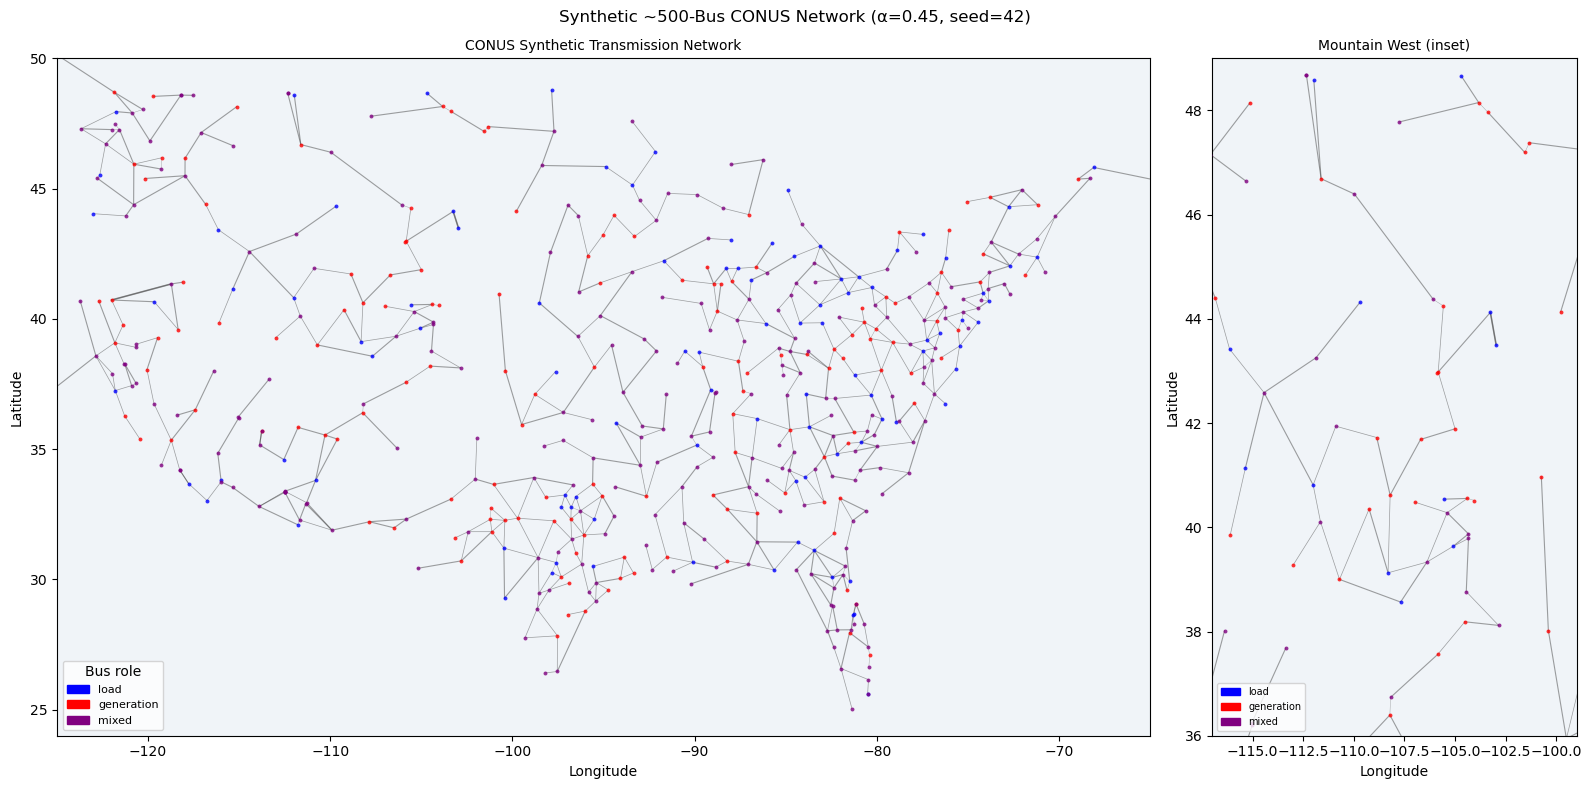

Static figure saved → /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/figures/synthetic_network_overview.png


In [20]:
# ── Static matplotlib figure for paper ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                          gridspec_kw={'width_ratios': [3, 1]})

ax_main = axes[0]
ax_inset = axes[1]

for ax, xlim, ylim, title in [
    (ax_main,  (-125, -65), (24, 50), 'CONUS Synthetic Transmission Network'),
    (ax_inset, (-117, -99), (36, 49), 'Mountain West (inset)'),
]:
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_facecolor('#f0f4f8')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    # Draw edges
    for _, edge in synthetic_branch_gdf.iterrows():
        if edge.geometry is None:
            continue
        xs, ys = edge.geometry.xy
        kv     = int(edge['voltage_assumed_kv'])
        lw     = {115: 0.3, 230: 0.5, 345: 0.8, 500: 1.2, 765: 1.8}.get(kv, 0.5)
        ax.plot(xs, ys, color='#444444', lw=lw, alpha=0.5)

    # Draw buses
    for role, color in ROLE_COLOR.items():
        mask = synthetic_bus_gdf['role'] == role
        ax.scatter(
            synthetic_bus_gdf.loc[mask, 'lon'],
            synthetic_bus_gdf.loc[mask, 'lat'],
            c=color, s=8, alpha=0.8, linewidths=0, label=role, zorder=5
        )

# Legend
patches = [mpatches.Patch(color=c, label=r) for r, c in ROLE_COLOR.items()]
ax_main.legend(handles=patches, loc='lower left', title='Bus role', fontsize=8)
ax_inset.legend(handles=patches, loc='lower left', fontsize=7)

fig.suptitle(
    f'Synthetic ~{len(synthetic_bus_gdf)}-Bus CONUS Network '
    f'(α={POP_WEIGHT_ALPHA}, seed={RANDOM_SEED})',
    fontsize=12
)
plt.tight_layout()
fig_path = FIGURES / 'synthetic_network_overview.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Static figure saved → {fig_path}')

## Cell 16 — Write outputs and update network_metadata.json

In [21]:
# ── Save synthetic buses ──────────────────────────────────────────────────────
buses_out = synthetic_bus_gdf[
    ['bus_id', 'ba_code', 'lon', 'lat', 'n_counties',
     'population', 'generation_cap_mw', 'load_mw', 'role', 'geometry']
].copy()
buses_path = PROCESSED / 'synthetic_buses.geojson'
buses_out.to_file(buses_path, driver='GeoJSON')
print(f'Saved {len(buses_out):,} buses → {buses_path}')

# ── Save synthetic branches ───────────────────────────────────────────────────
branches_out = synthetic_branch_gdf[
    ['line_id', 'from_bus', 'to_bus', 'length_km',
     'voltage_assumed_kv', 'thermal_mw', 'reactance_pu',
     'is_interregional', 'is_manual_override', 'is_eia930_calibrated',
     'is_density_fill', 'geometry']
].copy()
branches_path = PROCESSED / 'synthetic_branches.geojson'
branches_out.to_file(branches_path, driver='GeoJSON')
print(f'Saved {len(branches_out):,} branches → {branches_path}')

# ── Save plant assignments ────────────────────────────────────────────────────
assign_path = PROCESSED / 'synthetic_plant_assignments.parquet'
plant_assign_df.to_parquet(assign_path, index=False)
print(f'Saved {len(plant_assign_df):,} plant assignments → {assign_path}')

# ── Save validation JSON ──────────────────────────────────────────────────────
val_path = PROCESSED / 'synthetic_topology_validation.json'
with open(val_path, 'w') as f:
    json.dump(validation, f, indent=2, default=str)
print(f'Saved validation → {val_path}')

# ── Update network_metadata.json ──────────────────────────────────────────────
meta_path = PROCESSED / 'network_metadata.json'
with open(meta_path) as f:
    metadata = json.load(f)

metadata['synthetic_network'] = {
    'n_buses':                  int(len(synthetic_bus_gdf)),
    'n_edges':                  int(len(synthetic_branch_gdf)),
    'build_timestamp':          datetime.datetime.utcnow().isoformat() + 'Z',
    'pop_weight_alpha':         POP_WEIGHT_ALPHA,
    'population_resolution':    'county',
    'mountain_west_bus_count':  mw_buses,
    'wyoming_bus_count':        wy_buses,
    'interchange_percentile':   INTERCHANGE_PERCENTILE,
    'capacity_headroom_mult':   CAPACITY_HEADROOM_MULT,
    'random_seed':              RANDOM_SEED,
    'validation_status':        validation['validation_status'],
    'validation_warnings':      validation.get('warnings', []),
}

with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f'Updated {meta_path}')

# ── Final summary ─────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('Notebook 07 complete — synthetic topology build summary')
print('=' * 60)
print(f'  Buses     : {len(synthetic_bus_gdf):,}')
print(f'  Branches  : {len(synthetic_branch_gdf):,}')
print(f'  MW buses  : {mw_buses}  ({100*mw_buses/len(synthetic_bus_gdf):.1f}%)')
print(f'  WY buses  : {wy_buses}  (floor={WYOMING_BUS_FLOOR})')
print(f'  Status    : {validation["validation_status"].upper()}')
print('=' * 60)
print('Next: notebook 08 (validation deep-dive) or build_e4st_case.jl')

Saved 500 buses → /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/synthetic_buses.geojson
Saved 656 branches → /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/synthetic_branches.geojson
Saved 14,931 plant assignments → /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/synthetic_plant_assignments.parquet
Saved validation → /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/synthetic_topology_validation.json
Updated /Users/dylanhartman/Library/CloudStorage/OneDrive-UniversityofWyoming/Research/Energy Modeling/energy-map/data/processed/network_metadata.json

Notebook 07 complete — synthetic topology build summary
  Buses     : 500
  Branches  : 656
  MW buses  : 79  (15.8%)
  WY buses  : 12  (floor=6)
  Sta